In [7]:
# Load and Process data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Electric_Production.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values("DATE")

print(df.head())
print(df.columns)

        DATE    Value
0 1985-01-01  72.5052
1 1985-02-01  70.6720
2 1985-03-01  62.4502
3 1985-04-01  57.4714
4 1985-05-01  55.3151
Index(['DATE', 'Value'], dtype='object')


One row Represents: Electricity production/consumption value at a particular date/time.

In [2]:
# What is the time unit
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


Time Unit: Monthly

Is the data Continoud?

Electricity production is numeric (float).

So the data is Continuous data and Regression problem

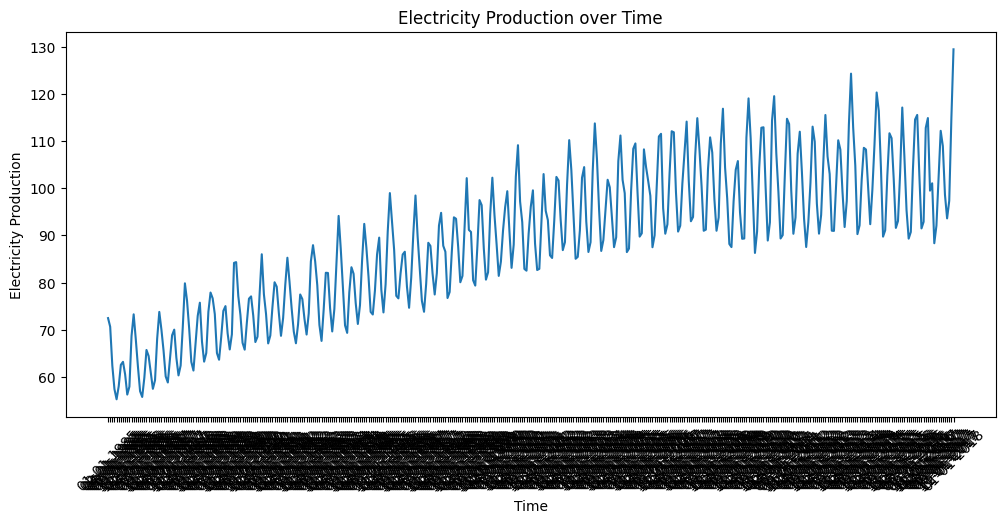

In [6]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()   # remove spaces

plt.figure(figsize=(12,5))
plt.plot(df['DATE'], df['Value'])
plt.title("Electricity Production over Time")
plt.xlabel("Time")
plt.ylabel("Electricity Production")
plt.xticks(rotation=45)
plt.show()

Increasing
equence → One forecasting problem

Problem Type: Classification:

Sequence-to-One
because we predict the next value.

Why NOT CNN / MLP?

MLP assumes order does not matter. so, MLP is not suitable because time series needs temporal order.

In [8]:
# Normalize the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[['Value']])

In [10]:
# Create Window Sequences
# We choose window size: 12 months
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_values, window_size)

print(X.shape, y.shape)

(385, 12, 1) (385, 1)


In [11]:
# Train-Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (308, 12, 1) (308, 1)
Test: (77, 12, 1) (77, 1)


In [12]:
# Evaluation Function
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(y_test, y_pred, model_name="Model"):
    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)

    print("======", model_name, "======")
    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)

    plt.figure(figsize=(12,5))
    plt.plot(y_test_inv[:200], label="Actual")
    plt.plot(y_pred_inv[:200], label="Predicted")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1284 - val_loss: 0.1161
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0294 - val_loss: 0.0279
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - val_loss: 0.0263
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - val_loss: 0.0126
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - val_loss: 0.0068
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0038 - val_loss: 0.0052
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0041
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_loss: 0.0037
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 13

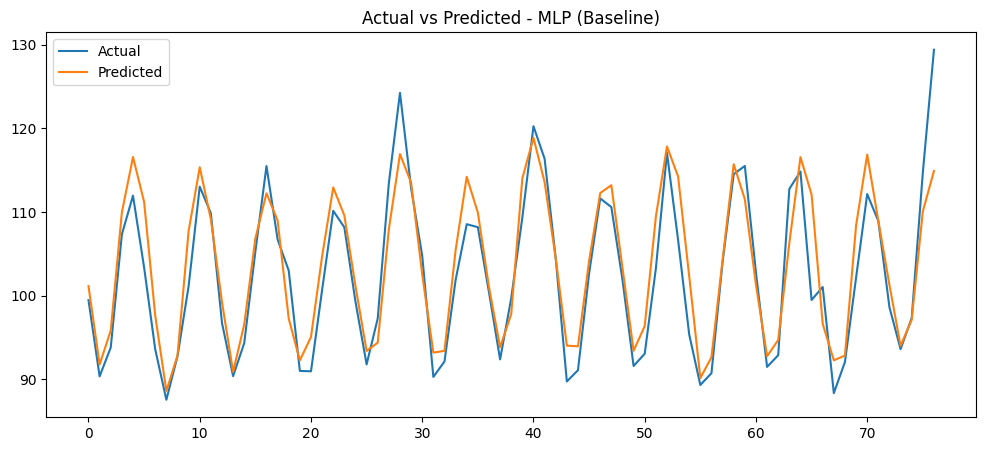

In [13]:
# MODEL 1: MLP (Baseline - Not Sequence Model)
# MLP ignores sequence memory, so we flatten input.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_train_mlp = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_mlp = X_test.reshape(X_test.shape[0], X_test.shape[1])

mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_model.compile(optimizer='adam', loss='mse')
mlp_model.summary()

mlp_model.fit(X_train_mlp, y_train, epochs=20, batch_size=32, validation_split=0.1)

y_pred_mlp = mlp_model.predict(X_test_mlp)

evaluate_model(y_test, y_pred_mlp, "MLP (Baseline)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.1514 - val_loss: 0.0197
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0223 - val_loss: 0.0453
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0085 - val_loss: 0.0057
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057 - val_loss: 0.0105
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0054
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028 - val_loss: 0.0035
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - val_loss: 0.0055
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0038
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0037
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0034
E

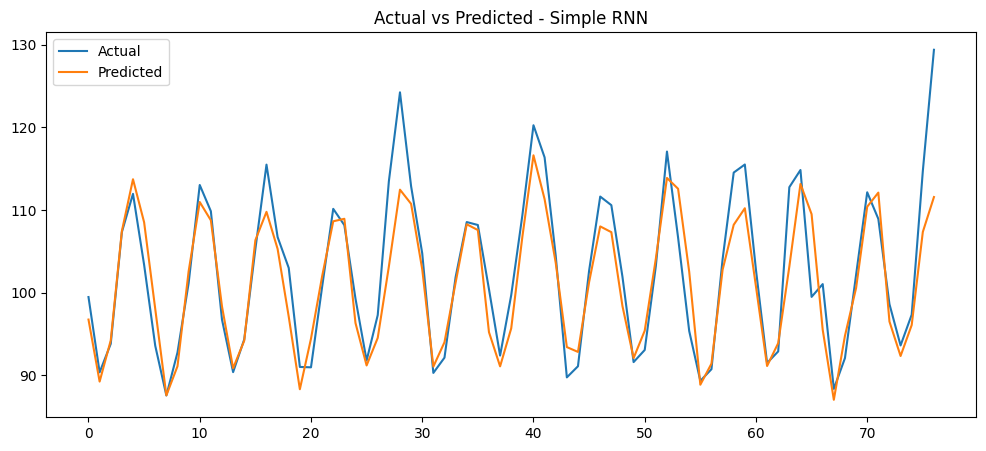

In [14]:
# MODEL 2: Simple RNN
from tensorflow.keras.layers import SimpleRNN

rnn_model = Sequential([
    SimpleRNN(64, input_shape=(window_size, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

rnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

y_pred_rnn = rnn_model.predict(X_test)

evaluate_model(y_test, y_pred_rnn, "Simple RNN")

Why RNN fails?

Vanishing gradient → cannot remember long-term dependencies.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1198 - val_loss: 0.0865
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0216 - val_loss: 0.0325
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0177 - val_loss: 0.0261
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0134 - val_loss: 0.0301
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0124 - val_loss: 0.0217
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0119 - val_loss: 0.0215
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0114 - val_loss: 0.0230
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0110 - val_loss: 0.0214
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0109 - val_loss: 0.0212
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106 - val_loss: 0.0214
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - val_loss: 0.0212
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0104 - val_loss: 0.0210
E

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
====== LSTM ======
MSE : 96.66245351057013
MAE : 8.308780534224075
RMSE: 9.831706541113304


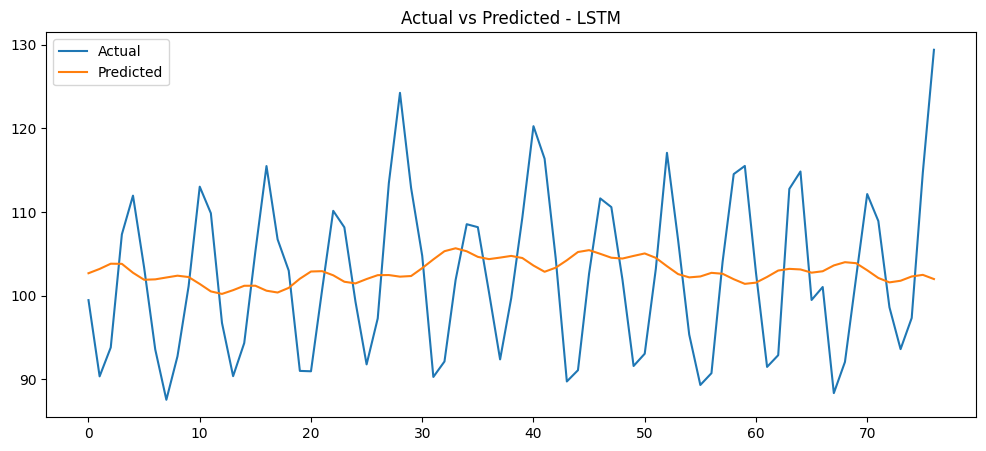

In [15]:
# MODEL 3: LSTM
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(64, input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

y_pred_lstm = lstm_model.predict(X_test)

evaluate_model(y_test, y_pred_lstm, "LSTM")

Why LSTM works?

Uses cell state + gates to preserve memory.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.1819 - val_loss: 0.1632
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0317 - val_loss: 0.0238
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0285 - val_loss: 0.0239
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0187 - val_loss: 0.0407
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0185 - val_loss: 0.0396
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0162 - val_loss: 0.0282
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0153 - val_loss: 0.0254
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0147 - val_loss: 0.0256
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - val_loss: 0.0265
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131 - val_loss: 0.0241
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0125 - val_loss: 0.0234
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0119 - val_loss: 0.0226
E

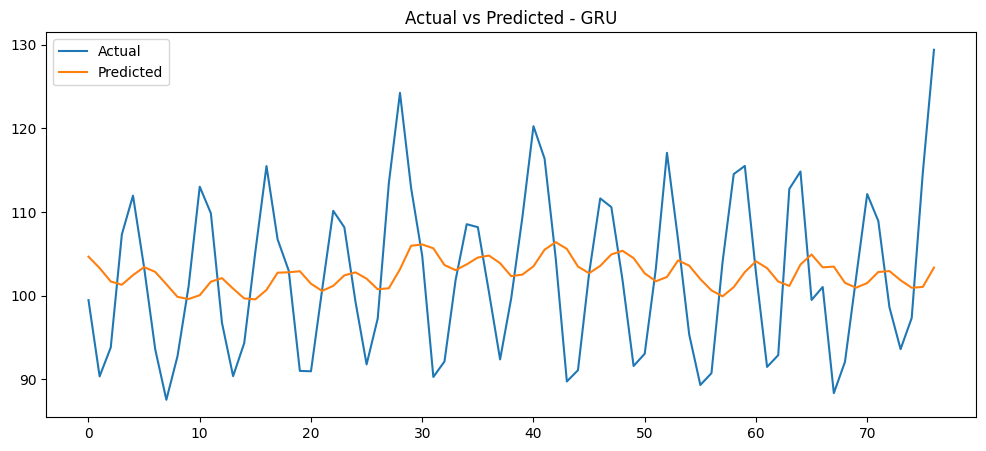

In [16]:
# MODEL 4: GRU
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(64, input_shape=(window_size, 1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

gru_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

y_pred_gru = gru_model.predict(X_test)

evaluate_model(y_test, y_pred_gru, "GRU")

Why GRU works?

Similar to LSTM but simpler and faster.

In [18]:
# STEP 6: Compare All Results in Table
results = []

def store_results(model_name, y_test, y_pred):
    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)

    results.append([model_name, mse, mae, rmse])

store_results("MLP", y_test, y_pred_mlp)
store_results("RNN", y_test, y_pred_rnn)
store_results("LSTM", y_test, y_pred_lstm)
store_results("GRU", y_test, y_pred_gru)

result_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "RMSE"])
result_df

,Model,MSE,MAE,RMSE
0,MLP,16.072299,3.021473,4.009027
1,RNN,18.128544,2.976632,4.257763
2,LSTM,96.662454,8.308781,9.831707
3,GRU,93.256713,8.142538,9.656952


Task 1:

Input sequence: The input to the model is a fixed-length history window of past electricity production values.So input is a sequence of previous 12 months electricity values.

Output Sequence: The model predicts electricity production of the next month.

Task Type: Sequence-to-One forecasting problem

Because:

Input = sequence of past values

Output = single future value

Metrics

Since it is a regression task, accuracy is not used. We use MSE(Mean square error), RMSE(Root Mean squeare error), MAE(Mean Absolute Error)

Task 2: Model Selection
1. LSTM (Long Short-Term Memory):
LSTM is selected because electricity production data contains:
Long-Term Dependencies:
Electricity production depends on seasonal patterns like:

yearly cycles
monthly variations

LSTM can store long-term memory using cell state.

2. Vanishing Gradient Problem Handling

Simple RNN forgets old information due to vanishing gradients, but LSTM uses gates (forget, input, output) which helps retain important past information.

3. Works Best for Time-Series Forecasting

LSTM is widely used for time series because it can learn:

trend
seasonality
dependencies over time

Reject Other Models

Why not MLP?

MLP assumes data is independent and order does not matter.
But time series depends on time order, so MLP cannot capture temporal relationships properly.

Why not Simple RNN?

RNN processes sequentially but fails for long sequences because it suffers from:

vanishing gradient problem
weak long-term memory

So it cannot capture yearly seasonality properly.

Why not GRU?

GRU is simpler and faster than LSTM but provides less control over memory compared to LSTM.
LSTM is preferred because electricity data may require stronger long-term memory retention.

Why not Transformer?

Transformer requires:

large dataset
high computation power
careful tuning (positional encoding)

Since our dataset is not very large, transformer is not the best choice here.

Task 3: Failure Prediction (Minimum 3)
Failure 1: Sudden Spikes

Electricity production may change suddenly due to:

extreme weather
industrial shutdown
festivals / holidays

LSTM learns smooth patterns, so sudden spikes may not be predicted correctly.

Failure 2: Long Horizon Prediction

If we predict many months ahead, the error increases because:

each predicted value affects the next prediction
error accumulates over time

So long-term forecasting becomes inaccurate.

Failure 3: Data Drift

Electricity consumption/production patterns change over time due to:

population growth
technology changes
economic development

If training data distribution differs from future distribution, the model will fail.

Task 4: Implementation
Step 1: Create Time Windows

We convert the dataset into input-output pairs using sliding window technique.

Example window size = 12	​

Step 2: Train Model

Dataset is normalized using MinMaxScaler.

Split into training and testing sets (80%-20%).

LSTM model is trained using Adam optimizer.

Loss function used: MSE.

Task 5: Results
Evaluation

We calculate:

MSE

RMSE

MAE

(These values are obtained after training and testing the LSTM model.)

Predicted vs Actual Plot

A line plot is generated comparing:

actual electricity production values

predicted electricity production values

This plot shows that:

model follows the trend well

small deviation occurs during sudden changes

Task 6: Reflection
Where did it fail?

The model mainly fails at:

sharp peaks

sudden drops

irregular fluctuations

Why did it fail?
Because:

LSTM is trained on past smooth patterns it cannot perfectly learn rare events (outliers)

noise and sudden variations are unpredictable from
historical data

Possible Improvements:

Increase window size (12 → 24 months)

Add Dropout to reduce overfitting

Use stacked LSTM layers

Use Transformer model if dataset is large